# QTableBot vs Round-Robin (RandomBot / ChaserBot / SmeshBot)

`agents.qtable_bot.QTableBot` is a from-scratch tabular Q-learning agent with no
hand-coded pursuit, attack, or recovery logic — everything it does is learned online,
one tick at a time. The original `qtable_vs_smesh.ipynb` trained one instance purely
against `agents.smesh_bot.SmeshBot`.

This notebook trains a **separate, fresh** `QTableBot` instance the same way, but
round-robin against `RandomBot -> ChaserBot -> SmeshBot -> repeat` (excluding
QTableBot itself, to avoid training against a moving target). 2000 headless matches,
the same instance reused throughout so its q-table persists and grows, logged to
MLflow every 100 matches. The resulting checkpoint can be compared against the
SmeshBot-only-trained one to see whether a broader training distribution generalizes
better or just dilutes learning.


In [2]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

from smeshlite.core.match import Match, MatchConfig
from agents.random_bot import RandomBot
from agents.chaser_bot import ChaserBot
from agents.smesh_bot import SmeshBot
from agents.qtable_bot import QTableBot


## Agent design recap

See `agents/qtable_bot.py` for the full docstring. In short:

- **State** (504 discrete states): bucketed `dx`/`dy` to the opponent, whether we're
  airborne, whether the opponent is mid-attack/charge, which third of the platform
  we're standing on, and whether we're in hitstun.
- **Actions** (8): `NONE, LEFT, RIGHT, UP, ATTACK, LEFT+ATTACK, RIGHT+ATTACK, UP+ATTACK`.
- **Reward**: `+dmg_scale * damage dealt`, `+ko_reward` for KO'ing the opponent,
  `-death_penalty` for losing a stock — the same shaping as `SmeshLiteEnv._compute_reward`.
- **Learning**: plain tabular Q-learning, updated every tick from the *previous*
  tick's (state, action) once this tick's reward/next-state are known.


In [3]:
qtable = QTableBot()  # persists across all matches below

N_MATCHES = 2000
LOG_EVERY = 100
EPSILON_START = 0.3
EPSILON_END = 0.02


def epsilon_for(match_idx: int) -> float:
    """Linear decay from EPSILON_START to EPSILON_END over N_MATCHES."""
    t = min(match_idx / N_MATCHES, 1.0)
    return EPSILON_START + (EPSILON_END - EPSILON_START) * t


## Training loop

Each match: set `qtable.epsilon` from the decay schedule, pick the next opponent from
the round-robin cycle `RandomBot -> ChaserBot -> SmeshBot -> repeat`, play a fresh
`Match` to completion (QTableBot as P0, a fresh opponent instance as P1), then record
the outcome. Every `LOG_EVERY` matches, aggregate the trailing window (overall and per
opponent) and log it to MLflow as a metric step. 2000 matches should take on the order
of a few minutes.


In [4]:
OPPONENT_CYCLE = [RandomBot, ChaserBot, SmeshBot]
OPPONENT_NAMES = ["RandomBot", "ChaserBot", "SmeshBot"]

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("qtable_vs_roundrobin")

history = []
t0 = time.time()

with mlflow.start_run(run_name=f"qtable_rr_{time.strftime('%Y%m%d_%H%M%S')}") as run:
    run_id = run.info.run_id
    mlflow.log_params({
        "alpha": qtable.alpha,
        "gamma": qtable.gamma,
        "dmg_scale": qtable.dmg_scale,
        "ko_reward": qtable.ko_reward,
        "death_penalty": qtable.death_penalty,
        "time_penalty": qtable.time_penalty,
        "n_actions": QTableBot.N_ACTIONS,
        "n_matches": N_MATCHES,
        "log_every": LOG_EVERY,
        "epsilon_start": EPSILON_START,
        "epsilon_end": EPSILON_END,
        "opponent_cycle": ", ".join(OPPONENT_NAMES),
    })

    for match_idx in range(1, N_MATCHES + 1):
        qtable.epsilon = epsilon_for(match_idx)
        opponent = OPPONENT_CYCLE[(match_idx - 1) % len(OPPONENT_CYCLE)]()
        opponent_name = OPPONENT_NAMES[(match_idx - 1) % len(OPPONENT_NAMES)]

        m = Match(MatchConfig())
        m.reset(n_players=2)
        m.set_player_brain(0, qtable)
        m.set_player_brain(1, opponent)
        qtable.new_episode()

        while not m.done:
            m.tick()

        history.append({
            "match": match_idx,
            "opponent": opponent_name,
            "winner": m.winner,
            "frames": m.frame,
            "episode_reward": qtable.episode_reward,
            "q_table_size": qtable.q_table_size,
            "epsilon": qtable.epsilon,
        })

        if match_idx % LOG_EVERY == 0:
            recent = pd.DataFrame(history[-LOG_EVERY:])
            win_rate = (recent["winner"] == 0).mean()
            avg_frames = recent["frames"].mean()
            avg_reward = recent["episode_reward"].mean()
            metrics = {
                "win_rate": win_rate,
                "avg_frames": avg_frames,
                "avg_reward": avg_reward,
                "q_table_size": qtable.q_table_size,
                "epsilon": qtable.epsilon,
            }
            for opp_name, group in recent.groupby("opponent"):
                metrics[f"win_rate_{opp_name}"] = (group["winner"] == 0).mean()
                metrics[f"avg_reward_{opp_name}"] = group["episode_reward"].mean()
            mlflow.log_metrics(metrics, step=match_idx)
            print(f"match {match_idx:5d}: win_rate={win_rate:.2f} avg_reward={avg_reward:+.3f} q_table_size={qtable.q_table_size}")

print(f"done in {time.time() - t0:.1f}s")
df = pd.DataFrame(history)
df.tail()


2026/06/11 19:32:10 INFO mlflow.tracking.fluent: Experiment with name 'qtable_vs_roundrobin' does not exist. Creating a new experiment.


match   100: win_rate=0.71 avg_reward=+3.202 q_table_size=323
match   200: win_rate=0.86 avg_reward=+4.079 q_table_size=338
match   300: win_rate=0.69 avg_reward=+3.225 q_table_size=343
match   400: win_rate=0.82 avg_reward=+3.897 q_table_size=344
match   500: win_rate=0.91 avg_reward=+4.246 q_table_size=352
match   600: win_rate=0.89 avg_reward=+4.323 q_table_size=354
match   700: win_rate=0.87 avg_reward=+4.202 q_table_size=355
match   800: win_rate=0.83 avg_reward=+4.053 q_table_size=356
match   900: win_rate=0.94 avg_reward=+4.239 q_table_size=356
match  1000: win_rate=0.98 avg_reward=+4.347 q_table_size=356
match  1100: win_rate=0.94 avg_reward=+4.050 q_table_size=356
match  1200: win_rate=0.96 avg_reward=+4.221 q_table_size=356
match  1300: win_rate=0.96 avg_reward=+4.118 q_table_size=356
match  1400: win_rate=0.94 avg_reward=+4.030 q_table_size=356
match  1500: win_rate=0.98 avg_reward=+4.581 q_table_size=356
match  1600: win_rate=0.98 avg_reward=+4.155 q_table_size=356
match  1

,match,opponent,winner,frames,episode_reward,q_table_size,epsilon
1995,1996,RandomBot,0,1182,3.1200,357,0.02056
1996,1997,ChaserBot,0,1077,5.8100,357,0.02042
1997,1998,SmeshBot,0,1120,4.7775,357,0.02028
1998,1999,RandomBot,0,1215,3.0500,357,0.02014
1999,2000,ChaserBot,0,1019,4.2300,357,0.02000


## Results


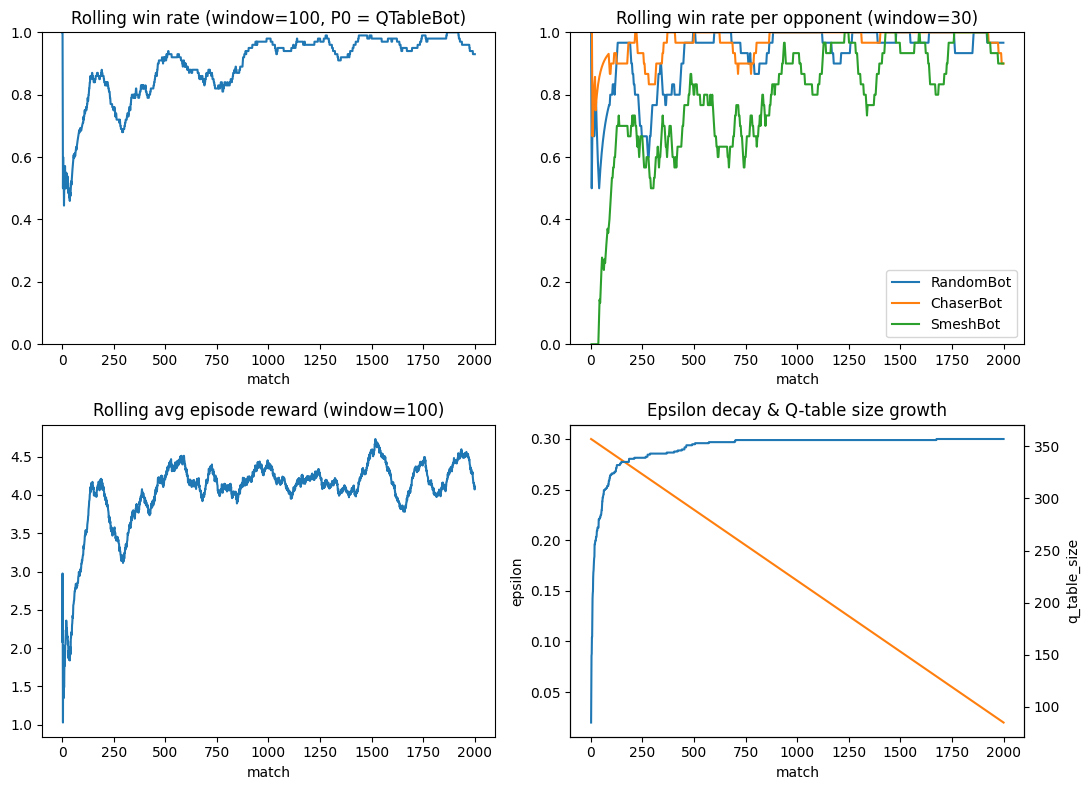

In [5]:
win_rolling = df["winner"].eq(0).rolling(100, min_periods=1).mean()
reward_rolling = df["episode_reward"].rolling(100, min_periods=1).mean()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(df["match"], win_rolling)
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_title("Rolling win rate (window=100, P0 = QTableBot)")
axes[0, 0].set_xlabel("match")

for opp_name in OPPONENT_NAMES:
    mask = df["opponent"] == opp_name
    opp_win_rolling = df.loc[mask, "winner"].eq(0).rolling(30, min_periods=1).mean()
    axes[0, 1].plot(df.loc[mask, "match"], opp_win_rolling, label=opp_name)
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_title("Rolling win rate per opponent (window=30)")
axes[0, 1].set_xlabel("match")
axes[0, 1].legend()

axes[1, 0].plot(df["match"], reward_rolling)
axes[1, 0].set_title("Rolling avg episode reward (window=100)")
axes[1, 0].set_xlabel("match")

ax_eps = axes[1, 1]
ax_eps.plot(df["match"], df["epsilon"], color="tab:orange", label="epsilon")
ax_eps.set_ylabel("epsilon")
ax_eps.set_xlabel("match")
ax_q = ax_eps.twinx()
ax_q.plot(df["match"], df["q_table_size"], color="tab:blue", label="q_table_size")
ax_q.set_ylabel("q_table_size")
axes[1, 1].set_title("Epsilon decay & Q-table size growth")

fig.tight_layout()


In [6]:
checkpoint_path = "agents/checkpoints/qtable_bot_roundrobin.json"
qtable.save(checkpoint_path)

with mlflow.start_run(run_id=run_id):
    mlflow.log_artifact(checkpoint_path)

print(f"Saved Q-table ({qtable.q_table_size} states) to {checkpoint_path}")


🏃 View run qtable_rr_20260611_193210 at: http://localhost:5000/#/experiments/4/runs/74a1d048e6a445a68a603c8959d5a183
🧪 View experiment at: http://localhost:5000/#/experiments/4
Saved Q-table (357 states) to agents/checkpoints/qtable_bot_roundrobin.json
